# GrC Image Matting on CBIS-DDSM - Layer 5, Evaluation and Ablation

Hybrid alpha generation, evaluation against the **real radiologist mask**, the four-arm ablation, and final consolidation.

Writes to Drive: `alpha_maps_full.npz`, `evaluation_per_*.csv`, `ablation_table.csv`, `final_results.json`, `results_summary.txt`.

## State restoration

In [ ]:
# Imports and config
!pip install -q opencv-python scikit-learn scipy tqdm joblib

import os, json, random, warnings, math, time
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
from numpy.lib.stride_tricks import sliding_window_view
from scipy import ndimage
from scipy.sparse import csr_matrix, diags
from scipy.sparse.linalg import spsolve
from scipy.spatial.distance import cdist
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
import joblib
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive', force_remount=False)

DRIVE_ROOT = "/content/drive/MyDrive/cbis_ddsm_grc_project"
CONFIG = json.load(open(os.path.join(DRIVE_ROOT, "config.json")))
globals().update(CONFIG)
SEED = CONFIG["SEED"]
random.seed(SEED); np.random.seed(SEED)

LAP_WINDOW, LAP_EPSILON = 3, 1e-7
MAX_TRAIN_PATCHES_PER_IMG = 300
ABLATION_N_PER_CLASS = 10
ABLATION_KEYS = ["baseline_3x3_manual", "mod2_5x5_single_scale",
                 "mod1234_no_hybrid", "full_method"]
print("Config loaded.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Config loaded.


In [ ]:
final_df_loaded = pd.read_csv(os.path.join(RESULTS_DIR, "final_df_loaded.csv"))
metadata_df     = pd.read_csv(os.path.join(PREPROCESSED_DIR, "preprocessing_metadata.csv"))
roi_arch    = np.load(os.path.join(PREPROCESSED_DIR, "rois.npz"))
trimap_arch = np.load(os.path.join(TRIMAPS_DIR, "trimaps.npz"))
gtmask_arch = np.load(os.path.join(PREPROCESSED_DIR, "gt_masks.npz"))
prob_arch   = np.load(os.path.join(OUTPUTS_DIR, "layer4_prob_maps.npz"))

lesion_of = dict(zip(metadata_df['image_id'], metadata_df['lesion_key']))
class_of  = dict(zip(final_df_loaded['image_id'], final_df_loaded['class']))
preprocessed_results = {}
for iid in roi_arch.files:
    preprocessed_results[iid] = {
        'image_id': iid, 'roi': roi_arch[iid],
        'trimap': trimap_arch[iid] if iid in trimap_arch.files else None,
        'gt_mask': gtmask_arch[iid] if iid in gtmask_arch.files else None,
        'lesion_key': lesion_of.get(iid), 'class': class_of.get(iid)}

layer4_maps = {iid: {'prob_map': prob_arch[iid], 'cls': class_of.get(iid)}
               for iid in prob_arch.files}

templates = np.load(os.path.join(MODELS_DIR, "kmeans_templates.npy"))
K_TEMPLATES = templates.shape[0]
svm    = joblib.load(os.path.join(MODELS_DIR, "svm_layer4.joblib"))
scaler = joblib.load(os.path.join(MODELS_DIR, "svm_scaler.joblib"))

layer1_ms_maps = {}
for ps in PATCH_SIZES:
    a = np.load(os.path.join(OUTPUTS_DIR, f"layer1_ms_lipw_{ps}x{ps}.npz"))
    for iid in a.files:
        if iid not in layer1_ms_maps:
            layer1_ms_maps[iid] = {'lipw_stack': np.zeros((*a[iid].shape, len(PATCH_SIZES)), np.float32)}
        layer1_ms_maps[iid]['lipw_stack'][:, :, PATCH_SIZES.index(ps)] = a[iid]

print(f"Restored {len(preprocessed_results)} images, {len(layer4_maps)} prob maps, K={K_TEMPLATES}")

Restored 537 images, 537 prob maps, K=16


## Sections 12 & 13 - Layer 5, evaluation, and the four-arm ablation

The curated CBIS-DDSM release contains abnormality cases
only; the normal studies in the original uncurated DDSM were not carried over. So
this section reports three per-class rows, not four.

In [ ]:
# Layer 5 functions 
def match_templates_signed(lipw_map, templates):
    h, w = lipw_map.shape
    K    = len(templates)
    ps   = templates.shape[1]
    half = ps // 2

    padded  = np.pad(lipw_map, half, mode='reflect').astype(np.float32)
    patches = sliding_window_view(padded, (ps, ps))
    pf      = patches.reshape(h * w, ps * ps).astype(np.float32)

    T  = templates.reshape(K, ps * ps).astype(np.float32)
    Tc = T - T.mean(axis=1, keepdims=True)
    W  = np.sign(Tc)
    W[W == 0] = 1.0

    Pc = pf - pf.mean(axis=1, keepdims=True)

    num   = Pc @ W.T
    denom = (np.linalg.norm(Pc, axis=1, keepdims=True) *
             np.linalg.norm(W, axis=1)[None, :] + 1e-8)
    corr  = num / denom
    score = (corr + 1.0) * 0.5
    return score.reshape(h, w, K).astype(np.float32)


def match_templates_old(lipw_map, templates):
    h, w = lipw_map.shape
    K    = len(templates)
    ps   = templates.shape[1]
    half = ps // 2

    padded  = np.pad(lipw_map, half, mode='reflect').astype(np.float32)
    patches = sliding_window_view(padded, (ps, ps))
    pf      = patches.reshape(h * w, ps * ps)
    tf      = templates.reshape(K, ps * ps)
    out     = np.zeros((h * w, K), dtype=np.float32)

    for k in range(K):
        t = tf[k]
        high = (t >= 0.7)
        low  = (t <= 0.3)
        med  = ~high & ~low
        sat  = np.zeros((h * w, ps * ps), dtype=np.float32)
        if high.any():
            sat[:, high] = pf[:, high]
        if low.any():
            sat[:, low] = 1.0 - pf[:, low]
        if med.any():
            sat[:, med] = 1.0 - np.abs(pf[:, med] - 0.5) * 2.0
        b = np.maximum(0, sat[:, :-1] + sat[:, 1:] - 1)
        out[:, k] = b.mean(axis=1)

    return out.reshape(h, w, K)

print("Both matchers defined (old is diagnostic only).")


def compute_histogram_map_fast(score_map, window_size=7, stride=1):
    h, w, k = score_map.shape
    half    = window_size // 2

    padded = np.pad(score_map, ((half, half), (half, half), (0, 0)),
                    mode='reflect').astype(np.float32)
    cs       = padded.cumsum(axis=0).cumsum(axis=1)
    integral = np.pad(cs, ((1, 0), (1, 0), (0, 0)), mode='constant')

    rows = list(range(0, h, stride))
    cols = list(range(0, w, stride))
    out  = np.zeros((len(rows), len(cols), k), dtype=np.float32)

    for oi, i in enumerate(rows):
        for oj, j in enumerate(cols):
            r1, c1 = i, j
            r2, c2 = i + window_size, j + window_size
            hist = (integral[r2, c2] - integral[r1, c2]
                    - integral[r2, c1] + integral[r1, c1])
            s = hist.sum()
            out[oi, oj] = hist / s if s > 1e-8 else np.ones(k, dtype=np.float32) / k

    return out

print("Layer 3 histogram function defined.")

INTENSITY_SCALES = [5, 9, 15]

def local_intensity_maps(roi, scales=INTENSITY_SCALES):
    return [cv2.boxFilter(roi.astype(np.float32), -1, (w, w),
                          borderType=cv2.BORDER_REFLECT) for w in scales]

def predict_prob_map(hist_map, roi, svm, scaler, batch=20000):
    hh, ww, k = hist_map.shape
    if roi.shape != (hh, ww):
        roi = cv2.resize(roi, (ww, hh), interpolation=cv2.INTER_LINEAR)
    ims = local_intensity_maps(roi)

    flat_hist = hist_map.reshape(-1, k)
    flat_int  = np.stack([im.reshape(-1) for im in ims], axis=1)
    flat = np.concatenate([flat_hist, flat_int], axis=1)

    out = np.zeros(len(flat), dtype=np.float32)
    for s in range(0, len(flat), batch):
        chunk = scaler.transform(flat[s:s+batch])
        out[s:s+batch] = svm.predict_proba(chunk)[:, 1]
    return out.reshape(hh, ww).astype(np.float32)

print("predict_prob_map updated to multi-scale intensity, matching the trained SVM's actual feature width.")


LAP_WINDOW, LAP_EPSILON = 3, 1e-7
def build_matting_laplacian(feat, win=LAP_WINDOW, eps=LAP_EPSILON):
    h, w = feat.shape
    n    = h * w
    half = win // 2
    idx  = np.arange(n).reshape(h, w)

    rows, cols, vals = [], [], []
    for i in range(half, h - half):
        for j in range(half, w - half):
            win_idx = idx[i-half:i+half+1, j-half:j+half+1].ravel()
            win_f   = feat[i-half:i+half+1, j-half:j+half+1].ravel().astype(np.float64)
            k   = len(win_f)
            mu  = win_f.mean()
            var = win_f.var() + eps / k
            diff = (win_f - mu).reshape(-1, 1)
            W = (1.0 + (diff @ diff.T) / var) / k
            for a in range(k):
                for b in range(k):
                    rows.append(win_idx[a])
                    cols.append(win_idx[b])
                    vals.append((1.0 if a == b else 0.0) - W[a, b])

    return csr_matrix((vals, (rows, cols)), shape=(n, n))

print("Matting Laplacian builder defined.")

def solve_alpha(prob_map, trimap, roi, max_nodes=MAX_NODES,
                lam=LAMBDA_PROPAGATION, gamma=HYBRID_GAMMA, use_hybrid=True):
    h0, w0 = prob_map.shape

    scale  = min(1.0, math.sqrt(max_nodes / float(h0 * w0)))
    hs, ws = max(8, int(round(h0 * scale))), max(8, int(round(w0 * scale)))

    prob_s = cv2.resize(prob_map, (ws, hs), interpolation=cv2.INTER_LINEAR)
    roi_s  = cv2.resize(roi,      (ws, hs), interpolation=cv2.INTER_LINEAR)
    if trimap is not None:
        tm_s = cv2.resize(trimap, (ws, hs), interpolation=cv2.INTER_NEAREST)
    else:
        tm_s = np.full((hs, ws), 128, np.uint8)

    L = build_matting_laplacian(prob_s)

    known  = ((tm_s == 255) | (tm_s == 0)).ravel().astype(np.float64)
    target = (tm_s == 255).ravel().astype(np.float64)

    D = diags(known)
    A = (L + lam * D).tocsc()
    b = lam * (known * target)

    try:
        alpha_flat = spsolve(A, b)
    except Exception as e:
        print(f"  solve failed ({e}); falling back to the probability map")
        alpha_flat = prob_s.ravel().astype(np.float64)

    alpha_s = np.clip(alpha_flat.reshape(hs, ws), 0, 1).astype(np.float32)

    if use_hybrid:
        inten = roi_s.astype(np.float32)
        rng_i = inten.max() - inten.min()
        inten = (inten - inten.min()) / rng_i if rng_i > 1e-8 else np.zeros_like(inten)
        alpha_s = np.clip(gamma * alpha_s + (1.0 - gamma) * inten, 0, 1)

    return cv2.resize(alpha_s, (w0, h0), interpolation=cv2.INTER_LINEAR).astype(np.float32)

print("Alpha solver defined.")
print("Layer 5 functions defined.")

Both matchers defined (old is diagnostic only).
Layer 3 histogram function defined.
predict_prob_map updated to multi-scale intensity, matching the trained SVM's actual feature width.
Matting Laplacian builder defined.
Alpha solver defined.
Layer 5 functions defined.


In [ ]:
# Batch alpha generation
def one_per_class(df, pool):
    out = {}
    for c in TARGET_CLASSES:
        for _, r in df[df['class'] == c].iterrows():
            if r['image_id'] in pool: out[c] = r['image_id']; break
    return out

sample_ids = one_per_class(final_df_loaded, layer4_maps)

print("Batch Layer 5 alpha generation...\n")
alpha_maps = {}
t0 = time.time()
for _, row in tqdm(final_df_loaded.iterrows(), total=len(final_df_loaded), desc="Layer 5"):
    iid = row['image_id']
    if iid not in layer4_maps:
        continue
    try:
        alpha_maps[iid] = {'alpha': solve_alpha(
            layer4_maps[iid]['prob_map'], preprocessed_results[iid]['trimap'],
            preprocessed_results[iid]['roi']), 'cls': row['class']}
    except Exception as e:
        print(f"  [SKIP] {iid}: {e}")
print(f"\n{len(alpha_maps)} alpha maps in {(time.time()-t0)/60:.1f} min")
np.savez_compressed(os.path.join(ALPHAS_DIR, "alpha_maps_full.npz"),
                    **{k: v['alpha'] for k, v in alpha_maps.items()})
print("Saved alpha_maps_full.npz")

Batch Layer 5 alpha generation...



Layer 5: 100%|██████████| 537/537 [04:22<00:00,  2.04it/s]



537 alpha maps in 4.4 min
Saved alpha_maps_full.npz


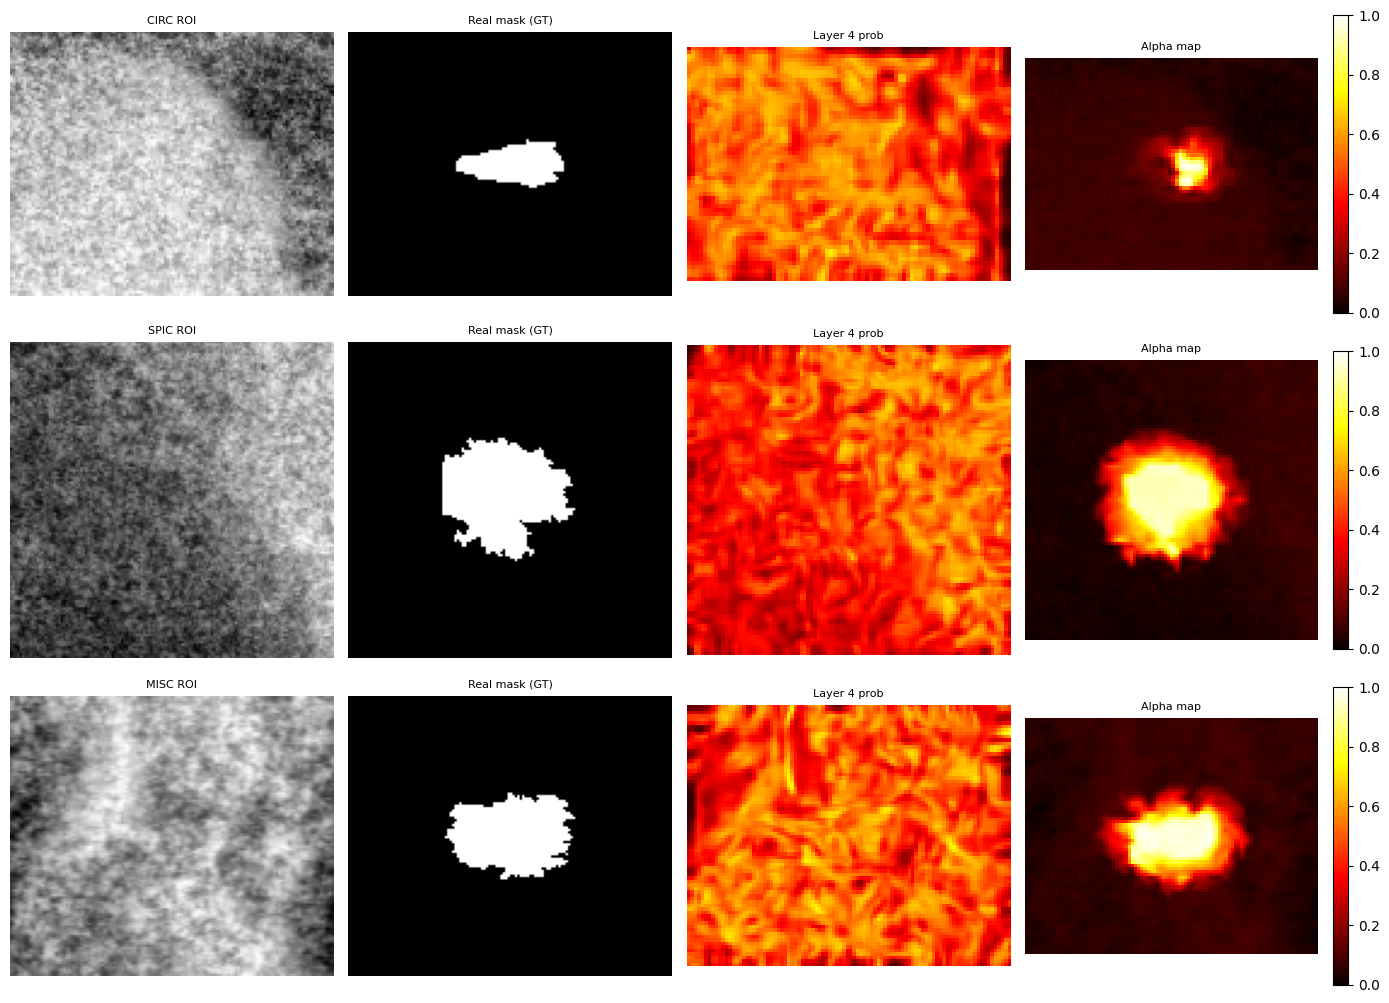

Saved section12_alpha_samples.png


In [ ]:
# Sample figure
n = len(sample_ids)
fig, axes = plt.subplots(n, 4, figsize=(14, 3.4*n))
if n == 1: axes = axes.reshape(1, -1)
for r, (cls, iid) in enumerate(sample_ids.items()):
    d = preprocessed_results[iid]
    axes[r,0].imshow(d['roi'], cmap='gray'); axes[r,0].set_title(f"{cls} ROI", fontsize=8)
    axes[r,1].imshow(d['gt_mask'], cmap='gray'); axes[r,1].set_title("Real mask (GT)", fontsize=8)
    axes[r,2].imshow(layer4_maps[iid]['prob_map'], cmap='hot', vmin=0, vmax=1)
    axes[r,2].set_title("Layer 4 prob", fontsize=8)
    im = axes[r,3].imshow(alpha_maps[iid]['alpha'], cmap='hot', vmin=0, vmax=1)
    axes[r,3].set_title("Alpha map", fontsize=8)
    plt.colorbar(im, ax=axes[r,3], fraction=0.046)
    for c in range(4): axes[r,c].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "section12_alpha_samples.png"), dpi=140, bbox_inches='tight')
plt.show()
print("Saved section12_alpha_samples.png")

In [ ]:
# Metrics defining 
def dice(pred, gt):
    inter = np.logical_and(pred, gt).sum()
    s = pred.sum() + gt.sum()
    return float(2 * inter / s) if s > 0 else np.nan

def sensitivity(pred, gt):
    tp = np.logical_and(pred, gt).sum()
    fn = np.logical_and(~pred, gt).sum()
    return float(tp / (tp + fn)) if (tp + fn) > 0 else np.nan

def specificity(pred, gt):
    tn = np.logical_and(~pred, ~gt).sum()
    fp = np.logical_and(pred, ~gt).sum()
    return float(tn / (tn + fp)) if (tn + fp) > 0 else np.nan

def hd95(pred, gt):
    if pred.sum() == 0 or gt.sum() == 0:
        return np.nan
    pe = pred ^ ndimage.binary_erosion(pred)
    ge = gt   ^ ndimage.binary_erosion(gt)
    pp, gp = np.argwhere(pe), np.argwhere(ge)
    if len(pp) == 0 or len(gp) == 0:
        return np.nan
    d1 = cdist(pp, gp).min(axis=1)
    d2 = cdist(gp, pp).min(axis=1)
    return float(np.percentile(np.concatenate([d1, d2]), HD95_PERCENTILE))

def alpha_mae(alpha, gt):
    return float(np.abs(alpha - gt.astype(np.float32)).mean())

print("Metrics defined.")
print("Metrics defined.")

Metrics defined.
Metrics defined.


In [ ]:
# Evaluation against the REAL mask (no circular GT)
def align_mask(shape, mask):
    if mask.shape[:2] == shape:
        return mask
    return cv2.resize(mask, (shape[1], shape[0]), interpolation=cv2.INTER_NEAREST)

def evaluate_alpha_realmask(iid, alpha, thr=ALPHA_THRESHOLD):
    d = preprocessed_results[iid]
    cls = d['class']
    gt = align_mask(alpha.shape, d['gt_mask']) > 127
    pred = alpha >= thr
    return {'image_id': iid, 'class': cls, 'lesion_key': d['lesion_key'],
            'dice': dice(pred, gt),
            'sensitivity': sensitivity(pred, gt),
            'specificity': specificity(pred, gt),
            'hd95': hd95(pred, gt),
            'alpha_mae': alpha_mae(alpha, gt)}

print("Evaluating alpha maps against real masks...\n")
rows = [evaluate_alpha_realmask(iid, d['alpha'])
        for iid, d in tqdm(alpha_maps.items(), total=len(alpha_maps), desc="eval")]
eval_df = pd.DataFrame(rows)
eval_df.to_csv(os.path.join(RESULTS_DIR, "evaluation_per_image.csv"), index=False)
print(f"\nEvaluated {len(eval_df)} images.")

Evaluating alpha maps against real masks...



eval: 100%|██████████| 537/537 [00:00<00:00, 742.22it/s]



Evaluated 537 images.


In [ ]:
# Per-class summary 
def summarise_per_class(df):
    out = []
    for cls in TARGET_CLASSES:
        sub = df[df['class'] == cls]
        if len(sub) == 0:
            continue
        out.append({'class': cls, 'n': len(sub),
                    'dice': sub['dice'].mean(), 'dice_std': sub['dice'].std(),
                    'sensitivity': sub['sensitivity'].mean(),
                    'specificity': sub['specificity'].mean(),
                    'hd95': sub['hd95'].mean(), 'alpha_mae': sub['alpha_mae'].mean()})
    return pd.DataFrame(out)

per_class = summarise_per_class(eval_df)
print("Per-class results (CIRC / SPIC / MISC, no NORM this phase):")
print(per_class.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
per_class.to_csv(os.path.join(RESULTS_DIR, "evaluation_per_class.csv"), index=False)
print("\nMetrics are always reported per class, never as a single average.")
print("GT is the real radiologist mask, so SPIC is no longer penalised by a circle.")

Per-class results (CIRC / SPIC / MISC, no NORM this phase):
class   n   dice  dice_std  sensitivity  specificity   hd95  alpha_mae
 CIRC 177 0.6736    0.1555       0.8686       0.9853 3.2775     0.0807
 SPIC 180 0.7615    0.1518       0.8347       0.9877 4.1928     0.0855
 MISC 180 0.7146    0.1536       0.8455       0.9866 3.8574     0.0836

Metrics are always reported per class, never as a single average.
GT is the real radiologist mask, so SPIC is no longer penalised by a circle.


In [ ]:
# Manual templates parametrised to K 
def make_manual_templates_k(k, ps=None):

    """Hand-designed shape detectors (vertical, horizontal, diagonals, cross,
    corner, blob, centre block, ring), returned as EXACTLY k patterns so the
    ablation arm's feature width matches the trained SVM. If k exceeds the base
    set, extra deterministic rotations are appended; if k is smaller, the set is
    truncated."""

    ps = PATCH_SINGLE if ps is None else ps
    c  = ps // 2
    def blank():
        return np.full((ps, ps), 0.2, np.float32)

    base = []
    t = blank(); t[:, c] = 0.9; base.append(t)                         
    t = blank(); t[c, :] = 0.9; base.append(t)                         
    t = blank(); np.fill_diagonal(t, 0.9); base.append(t)              
    t = blank(); np.fill_diagonal(np.fliplr(t), 0.9); base.append(t)   
    t = blank(); t[c, :] = 0.9; t[:, c] = 0.9; base.append(t)          
    t = blank(); t[0, :] = 0.9; t[:, 0] = 0.9; base.append(t)          
    t = np.full((ps, ps), 0.9, np.float32); t[c, c] = 0.2; base.append(t)  
    t = blank(); t[c-1:c+2, c-1:c+2] = 0.9; base.append(t)             

    out = list(base)
    i = 0
    while len(out) < k:                       
        out.append(np.rot90(base[i % len(base)], 1 + (i // len(base))))
        i += 1
    return np.stack(out[:k]).astype(np.float32)

manual_templates = make_manual_templates_k(K_TEMPLATES)
mt = manual_templates
print(f"Manual templates: {manual_templates.shape} (parametrised to K={K_TEMPLATES})")
print(f"  high {int((mt>=0.7).sum())}, low {int((mt<=0.3).sum())}, "
      f"medium {int(((mt>0.3)&(mt<0.7)).sum())} (bimodal by construction)")
assert manual_templates.shape[0] == K_TEMPLATES, "manual template count != K"
print("Count matches K, so the ablation arm's feature width will match the SVM.")

Manual templates: (16, 5, 5) (parametrised to K=16)
  high 142, low 258, medium 0 (bimodal by construction)
Count matches K, so the ablation arm's feature width will match the SVM.


In [ ]:
# Ablation runner function(evaluates against the real mask)
def run_ablation_arm(key, scales, tmpl, use_hybrid, subset_ids):
    print(f"\n{'='*54}\nAblation arm: {key}\n{'='*54}")
    print(f"  scales={scales}  templates={tmpl.shape[0]}  hybrid={use_hybrid}")
    rows = []
    for iid in tqdm(subset_ids, desc=key):
        if iid not in layer1_ms_maps:
            continue
        stack = layer1_ms_maps[iid]['lipw_stack']
        sel = [PATCH_SIZES.index(s) for s in scales]
        lipw = stack[:, :, sel].mean(axis=2) if len(sel) > 1 else stack[:, :, sel[0]]
        sm = match_templates_signed(lipw, tmpl)
        hm = compute_histogram_map_fast(sm, HISTOGRAM_WINDOW, HISTOGRAM_STRIDE)
        if hm.shape[2] != K_TEMPLATES:
            continue
        pm = predict_prob_map(hm, preprocessed_results[iid]['roi'], svm, scaler)
        a = solve_alpha(pm, preprocessed_results[iid]['trimap'],
                        preprocessed_results[iid]['roi'], use_hybrid=use_hybrid)
        rows.append(evaluate_alpha_realmask(iid, a))
    df = pd.DataFrame(rows)
    if len(df) == 0:
        print("  no results"); return None
    summary = {'key': key, 'n': len(df),
               'dice': float(df['dice'].mean()),
               'sensitivity': float(df['sensitivity'].mean()),
               'specificity': float(df['specificity'].mean()),
               'hd95': float(df['hd95'].mean()),
               'alpha_mae': float(df['alpha_mae'].mean())}
    print(f"  Dice={summary['dice']:.4f}  Sens={summary['sensitivity']:.4f}  "
          f"MAE={summary['alpha_mae']:.4f}")
    return {'summary': summary, 'per_image': df}

print("Ablation runner defined.")

Ablation runner defined.


In [ ]:
# Run the 4-arm ablation on a stratified subset
rng = np.random.default_rng(SEED)
subset = []
for cls in TARGET_CLASSES:
    ids = [r['image_id'] for _, r in final_df_loaded.iterrows()
           if r['class'] == cls and r['image_id'] in alpha_maps]
    if ids:
        subset.extend(list(rng.choice(ids, min(ABLATION_N_PER_CLASS, len(ids)), replace=False)))
print(f"Ablation subset: {len(subset)} images ({ABLATION_N_PER_CLASS}/class)\n")

arms = [
    ("baseline_3x3_manual",   [3],       manual_templates, False),
    ("mod2_5x5_single_scale", [5],       templates,        False),
    ("mod1234_no_hybrid",     [3, 5, 7], templates,        False),
    ("full_method",           [3, 5, 7], templates,        True),
]
ablation_out = {}
for key, scales, tmpl, hyb in arms:
    r = run_ablation_arm(key, scales, tmpl, hyb, subset)
    if r: ablation_out[key] = r

ablation_table = pd.DataFrame([v['summary'] for v in ablation_out.values()])
print("\n" + "=" * 70); print("ABLATION SUMMARY"); print("=" * 70)
print(ablation_table.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
ablation_table.to_csv(os.path.join(RESULTS_DIR, "ablation_table.csv"), index=False)

Ablation subset: 30 images (10/class)


Ablation arm: baseline_3x3_manual
  scales=[3]  templates=16  hybrid=False


baseline_3x3_manual: 100%|██████████| 30/30 [05:23<00:00, 10.78s/it]


  Dice=0.7048  Sens=0.8834  MAE=0.0301

Ablation arm: mod2_5x5_single_scale
  scales=[5]  templates=16  hybrid=False


mod2_5x5_single_scale: 100%|██████████| 30/30 [05:22<00:00, 10.74s/it]


  Dice=0.6692  Sens=0.8401  MAE=0.0306

Ablation arm: mod1234_no_hybrid
  scales=[3, 5, 7]  templates=16  hybrid=False


mod1234_no_hybrid: 100%|██████████| 30/30 [05:21<00:00, 10.73s/it]


  Dice=0.6681  Sens=0.8398  MAE=0.0307

Ablation arm: full_method
  scales=[3, 5, 7]  templates=16  hybrid=True


full_method: 100%|██████████| 30/30 [05:24<00:00, 10.80s/it]

  Dice=0.6703  Sens=0.8493  MAE=0.0843

ABLATION SUMMARY
                  key  n   dice  sensitivity  specificity   hd95  alpha_mae
  baseline_3x3_manual 30 0.7048       0.8834       0.9849 3.5095     0.0301
mod2_5x5_single_scale 30 0.6692       0.8401       0.9853 3.6883     0.0306
    mod1234_no_hybrid 30 0.6681       0.8398       0.9853 3.6795     0.0307
          full_method 30 0.6703       0.8493       0.9847 3.6537     0.0843


## Section 14 - Consolidation

Writes `final_results.json` and the plain-text `results_summary.txt`.

In [ ]:
# Consolidate and write summary
final_results = {
    'project'    : 'GrC-Based Image Matting on CBIS-DDSM',
    'base_paper' : 'Hu, Pang, Shi (2016), Knowledge-Based Systems 102, 51-63',
    'dataset'    : {'name': 'CBIS-DDSM (awsaf49 mirror)',
                    'images': int(len(final_df_loaded)),
                    'lesions': int(final_df_loaded['lesion_key'].nunique()),
                    'classes': {c: int((final_df_loaded['class'] == c).sum())
                                for c in TARGET_CLASSES}},
    'config'     : {'seed': SEED, 'patch_sizes': PATCH_SIZES,
                    'K_templates': int(K_TEMPLATES),
                    'hybrid_gamma': HYBRID_GAMMA, 'roi_max_size': ROI_MAX_SIZE},
    'scope_vs_mias': {
        'no_norm_class': 'CBIS-DDSM curated release has abnormality cases only',
        'real_mask_gt' : 'GT is the radiologist mask, not a circle; removes the '
                         'circular-GT penalty that weakened SPIC in MIAS',
        'multi_view'   : 'CC and MLO kept as separate images; split grouped by lesion'},
    'svm'        : json.load(open(os.path.join(RESULTS_DIR, "svm_results.json"))),
    'per_class'  : per_class.to_dict(orient='records'),
    'ablation'   : ablation_table.to_dict(orient='records'),
    'n_alpha_maps': len(alpha_maps),
}
json.dump(final_results, open(os.path.join(RESULTS_DIR, "final_results.json"), 'w'),
          indent=2, default=float)

lines = ["GrC IMAGE MATTING ON CBIS-DDSM - RESULTS SUMMARY", "=" * 52, "",
         f"Images evaluated : {len(eval_df)}",
         f"Lesions          : {final_df_loaded['lesion_key'].nunique()}",
         f"Templates (K)    : {K_TEMPLATES}",
         f"SVM test acc     : {final_results['svm']['test_acc']:.4f}", "",
         "Per-class results (no NORM class this phase)", "-" * 52,
         per_class.to_string(index=False, float_format=lambda x: f"{x:.4f}"), "",
         "Ablation", "-" * 52,
         ablation_table.to_string(index=False, float_format=lambda x: f"{x:.4f}"), "",
         "Scope notes", "-" * 52,
         "1. No NORM class: CBIS-DDSM curated release has abnormality cases only.",
         "2. GT is the real radiologist mask, not a circle. SPIC is no longer",
         "   penalised by circular GT (the main MIAS limitation for SPIC).",
         "3. CC and MLO kept separate; train/test split grouped by lesion_key.",
         f"4. Ablation on {ABLATION_N_PER_CLASS} images/class; Layer 5 on {MAX_NODES}-node grid.",
         "5. Layer 4 uses sklearn RBF-SVM in place of the paper's PSVM."]
summary = "\n".join(lines)
open(os.path.join(RESULTS_DIR, "results_summary.txt"), 'w').write(summary)
print(summary)

GrC IMAGE MATTING ON CBIS-DDSM - RESULTS SUMMARY

Images evaluated : 537
Lesions          : 270
Templates (K)    : 16
SVM test acc     : 0.5593

Per-class results (no NORM class this phase)
----------------------------------------------------
class   n   dice  dice_std  sensitivity  specificity   hd95  alpha_mae
 CIRC 177 0.6736    0.1555       0.8686       0.9853 3.2775     0.0807
 SPIC 180 0.7615    0.1518       0.8347       0.9877 4.1928     0.0855
 MISC 180 0.7146    0.1536       0.8455       0.9866 3.8574     0.0836

Ablation
----------------------------------------------------
                  key  n   dice  sensitivity  specificity   hd95  alpha_mae
  baseline_3x3_manual 30 0.7048       0.8834       0.9849 3.5095     0.0301
mod2_5x5_single_scale 30 0.6692       0.8401       0.9853 3.6883     0.0306
    mod1234_no_hybrid 30 0.6681       0.8398       0.9853 3.6795     0.0307
          full_method 30 0.6703       0.8493       0.9847 3.6537     0.0843

Scope notes
-----------------

In [ ]:
# Final notebook verification
print("=" * 60); print("OUTPUT INVENTORY"); print("=" * 60)
expected = [
    (OUTPUTS_DIR, "layer2_score_maps.npz"), (OUTPUTS_DIR, "layer3_histogram_maps.npz"),
    (OUTPUTS_DIR, "layer4_prob_maps.npz"), (ALPHAS_DIR, "alpha_maps_full.npz"),
    (MODELS_DIR, "svm_layer4.joblib"), (MODELS_DIR, "kmeans_templates.npy"),
    (RESULTS_DIR, "evaluation_per_image.csv"), (RESULTS_DIR, "evaluation_per_class.csv"),
    (RESULTS_DIR, "ablation_table.csv"), (RESULTS_DIR, "final_results.json"),
    (RESULTS_DIR, "results_summary.txt"), (FIGURES_DIR, "section12_alpha_samples.png"),
]
all_ok = True
for d, f in expected:
    p = os.path.join(d, f)
    print(f"  {'OK  ' if os.path.exists(p) else 'MISS'} {f}")
    all_ok = all_ok and os.path.exists(p)
print("=" * 60)
print("Sections 12-14 complete. CBIS-DDSM phase done." if all_ok else "Some outputs missing.")
print("Next: run the report-diagrams notebook, then write the progress report.")

OUTPUT INVENTORY
  OK   layer2_score_maps.npz
  OK   layer3_histogram_maps.npz
  OK   layer4_prob_maps.npz
  OK   alpha_maps_full.npz
  OK   svm_layer4.joblib
  OK   kmeans_templates.npy
  OK   evaluation_per_image.csv
  OK   evaluation_per_class.csv
  OK   ablation_table.csv
  OK   final_results.json
  OK   results_summary.txt
  OK   section12_alpha_samples.png
Sections 12-14 complete. CBIS-DDSM phase done.
Next: run the report-diagrams notebook, then write the progress report.
